# NorthStar Urban Mobility — SQL in R and R Analytics
**Tools:** RCurl · sqldf · dplyr · ggplot2

> **Important:** Go to **Runtime → Change runtime type → R** before running.

In [40]:
install.packages("RCurl")
install.packages("sqldf")
install.packages("dplyr")
install.packages("ggplot2")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



## 1. Load the Dataset from GitHub

In [58]:
library(RCurl)
library(sqldf)
library(dplyr)
library(ggplot2)

# Define the base path once
url <- "https://raw.githubusercontent.com/adamandreea0702-sys/NorthStar-Analytics/main/data/northstar_dataset.csv/"

# Load all CSV files in one loop
files <- c("customers", "orders", "deliveries", "drivers", "vehicles",
           "hubs", "incidents", "complaints", "app_events")

for (f in files) {
  x <- getURL(paste0(url, f, ".csv"))
  assign(f, read.csv(text = x))
}

cat("Files loaded successfully.\n")
head(deliveries)

Files loaded successfully.


,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>
1,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05
2,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
3,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51
4,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62
5,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22
6,DL00006,O00029,D037,V098,H03,2024-09-11 12:40:00,2024-09-12 17:11:52.384869,Delayed,13.84,0,0,1.57,9.58


## 2. Data Cleaning

In [43]:
# Standardise zone names across all files
standardise_zone <- function(x) {
  raw   <- c("AIRPORT","Airport","NORTH","North","north","SOUTH","South",
             "EAST","East","WEST","West","CENTRAL","Central","Ctr",
             "RiverSide","Riverside")
  clean <- c("Airport","Airport","North","North","North","South","South",
             "East","East","West","West","Central","Central","Central",
             "Riverside","Riverside")
  idx <- match(x, raw)
  ifelse(is.na(idx), x, clean[idx])
}

customers$home_zone     <- standardise_zone(customers$home_zone)
orders$pickup_zone      <- standardise_zone(orders$pickup_zone)
orders$dropoff_zone     <- standardise_zone(orders$dropoff_zone)
drivers$base_zone       <- standardise_zone(drivers$base_zone)
vehicles$assigned_zone  <- standardise_zone(vehicles$assigned_zone)

cat("Zone standardisation complete.\n")

Zone standardisation complete.


In [44]:
# Impute missing values with median
deliveries$customer_rating_post_delivery[is.na(deliveries$customer_rating_post_delivery)] <-
  median(deliveries$customer_rating_post_delivery, na.rm=TRUE)
drivers$training_score[is.na(drivers$training_score)] <-
  median(drivers$training_score, na.rm=TRUE)
vehicles$battery_health_pct[is.na(vehicles$battery_health_pct)] <-
  median(vehicles$battery_health_pct, na.rm=TRUE)
customers$loyalty_score[is.na(customers$loyalty_score)] <-
  median(customers$loyalty_score, na.rm=TRUE)

cat("Missing values imputed.\n")

Missing values imputed.


In [45]:
# Binary outcome flags
deliveries$is_failed  <- as.integer(deliveries$delivery_status == "Failed")
deliveries$is_delayed <- as.integer(deliveries$delivery_status == "Delayed")

## 3. SQL Queries Using sqldf

### Query 1 — Delivery failure rate by zone

In [46]:
result <- sqldf("
SELECT
    o.pickup_zone AS zone,
    COUNT(d.delivery_id) AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed,
    ROUND(100.0 * SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END)
          / COUNT(d.delivery_id), 2) AS failure_rate_pct,
    ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_rating,
    ROUND(AVG(d.manual_route_override_count), 2) AS avg_overrides
FROM deliveries d
JOIN orders o ON d.order_id = o.order_id
WHERE o.pickup_zone IS NOT NULL
GROUP BY o.pickup_zone
ORDER BY failure_rate_pct DESC
")
print(result)

       zone total_deliveries failed failure_rate_pct avg_rating avg_overrides
1   Central              174     33            18.97       3.56          1.29
2     North              135     22            16.30       3.90          0.70
3 Riverside              119     18            15.13       3.87          0.73
4      West              114     14            12.28       3.90          0.81
5      East              156     19            12.18       3.91          0.79
6   Airport              113     12            10.62       3.99          1.81
7     South              139     14            10.07       4.05          0.69


### Query 2 — Top 15 drivers with highest failure rates (min 5 deliveries)

In [47]:
result <- sqldf("
SELECT
    d.driver_id,
    dr.base_zone,
    dr.employment_type,
    ROUND(dr.training_score, 1) AS training_score,
    COUNT(d.delivery_id) AS deliveries,
    ROUND(100.0 * SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END)
          / COUNT(d.delivery_id), 1) AS failure_rate_pct,
    ROUND(AVG(d.manual_route_override_count), 2) AS avg_overrides
FROM deliveries d
JOIN drivers dr ON d.driver_id = dr.driver_id
GROUP BY d.driver_id, dr.base_zone, dr.employment_type, dr.training_score
HAVING COUNT(d.delivery_id) >= 5
ORDER BY failure_rate_pct DESC
LIMIT 15
")
print(result)

   driver_id base_zone employment_type training_score deliveries
1       D092      East        FullTime           88.2          5
2       D104      West        FullTime           87.7          7
3       D024 Riverside        PartTime           71.4          8
4       D010      West        FullTime           70.0          7
5       D005     North        FullTime           69.7          5
6       D095      West        FullTime           99.0          5
7       D143   Central        FullTime           68.5          5
8       D144      West        FullTime           85.0          5
9       D004   Airport        PartTime           88.9          9
10      D023      East        FullTime           79.1          6
11      D078     North        FullTime           73.7          6
12      D082      West        PartTime           74.1          6
13      D083     North        FullTime           80.8          9
14      D131     South        FullTime           86.7          9
15      D133     South   

### Query 3 — Ghost-completed problem

In [48]:
result <- sqldf("
SELECT
    c.complaint_type,
    d.delivery_status,
    COUNT(*) AS complaint_count,
    ROUND(AVG(c.resolution_days), 1) AS avg_resolution_days
FROM complaints c
LEFT JOIN deliveries d ON c.order_id = d.order_id
WHERE d.delivery_status IS NOT NULL
GROUP BY c.complaint_type, d.delivery_status
ORDER BY complaint_type, delivery_status
")
print(result)

# Ghost-completed subset
ghost <- result[result$delivery_status == "OnTime", ]
cat("\nComplaints against OnTime deliveries:\n")
print(ghost[order(-ghost$complaint_count), ])

      complaint_type delivery_status complaint_count avg_resolution_days
1           AppIssue         Delayed               7                10.6
2           AppIssue          Failed               5                10.6
3           AppIssue          OnTime              25                 8.6
4            Billing         Delayed               3                 7.0
5            Billing          Failed               2                 7.0
6            Billing          OnTime               7                 7.7
7             Damage         Delayed               1                16.0
8             Damage          Failed               2                11.0
9             Damage          OnTime               8                 9.6
10             Delay         Delayed              19                 6.9
11             Delay          Failed              10                 8.6
12             Delay          OnTime              44                 7.1
13   DriverBehaviour         Delayed               

### Query 4 — Hub incident rates

In [49]:
result <- sqldf("
SELECT
    h.hub_id,
    h.hub_name,
    h.zone,
    COUNT(DISTINCT d.delivery_id) AS total_deliveries,
    COUNT(DISTINCT i.incident_id) AS total_incidents,
    ROUND(100.0 * COUNT(DISTINCT i.incident_id)
          / COUNT(DISTINCT d.delivery_id), 1) AS incident_rate_pct,
    ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_rating
FROM hubs h
LEFT JOIN deliveries d ON h.hub_id = d.hub_id
LEFT JOIN incidents  i ON d.delivery_id = i.delivery_id
GROUP BY h.hub_id, h.hub_name, h.zone
ORDER BY incident_rate_pct DESC
")
print(result)

  hub_id       hub_name      zone total_deliveries total_incidents
1    H05   Central Core   Central              115              39
2    H03      East Dock      East              119              38
3    H02     South Link     South              106              33
4    H06    Airport Hub   Airport              104              32
5    H07  Riverside Hub Riverside              115              35
6    H08  Midtown Relay   Central              128              38
7    H04      West Gate      West              127              34
8    H01 North Exchange     North              136              31
  incident_rate_pct avg_rating
1              33.9       3.68
2              31.9       3.90
3              31.1       3.93
4              30.8       3.89
5              30.4       3.87
6              29.7       3.89
7              26.8       3.91
8              22.8       3.84


### Query 5 — Service contract margin by zone

In [50]:
result <- sqldf("
SELECT
    o.service_type,
    o.pickup_zone AS zone,
    COUNT(d.delivery_id) AS deliveries,
    ROUND(AVG(o.order_value), 2) AS avg_order_value,
    ROUND(AVG(d.fuel_or_charge_cost), 2) AS avg_fuel_cost,
    ROUND(AVG(o.order_value - d.fuel_or_charge_cost), 2) AS avg_margin
FROM deliveries d
JOIN orders o ON d.order_id = o.order_id
WHERE o.pickup_zone IS NOT NULL
GROUP BY o.service_type, o.pickup_zone
ORDER BY avg_margin ASC
")
print(result)

   service_type      zone deliveries avg_order_value avg_fuel_cost avg_margin
1      Business      West         12           71.36         13.22      58.15
2        Parcel Riverside         28           71.70         12.10      59.60
3       Medical     North         18           72.24         12.36      59.88
4        Retail      West         22           72.69         11.18      61.52
5       Medical      East         19           75.17         12.92      62.25
6        Retail      East         34           74.72         12.05      62.67
7      Business   Airport         13           83.22         18.78      64.44
8        Parcel     North         27           79.00         12.52      66.48
9     Passenger   Central         47           78.89         12.15      66.74
10       Retail   Central         49           80.20         12.85      67.35
11     Business     South         19           82.07         13.04      69.03
12      Medical      West         17           82.13         11.

## 4. Query Optimisation — Index Creation

In [51]:
# Create indexes on most frequently joined and filtered columns
# INDEX 1: deliveries(order_id) — used in every JOIN between deliveries and orders
sqldf("CREATE INDEX IF NOT EXISTS idx_del_order  ON deliveries(order_id)")

# INDEX 2: orders(pickup_zone) — most frequent filter and GROUP BY column
sqldf("CREATE INDEX IF NOT EXISTS idx_ord_zone   ON orders(pickup_zone)")

# INDEX 3: complaints(order_id) — used in ghost-completed query JOIN
sqldf("CREATE INDEX IF NOT EXISTS idx_comp_order ON complaints(order_id)")

# INDEX 4: incidents(delivery_id) — used in hub incident rate query
sqldf("CREATE INDEX IF NOT EXISTS idx_inc_del    ON incidents(delivery_id)")

# INDEX 5: deliveries(driver_id) — used in driver performance JOIN
sqldf("CREATE INDEX IF NOT EXISTS idx_del_driver ON deliveries(driver_id)")

# INDEX 6: deliveries(hub_id) — used in hub analysis JOIN
sqldf("CREATE INDEX IF NOT EXISTS idx_del_hub    ON deliveries(hub_id)")

cat("All 6 indexes created.\n")
cat("Indexes reduce row scans from full table size to only matching rows.\n")

Warning message in result_fetch(res@ptr, n = n):
“`dbGetQuery()`, `dbSendQuery()` and `dbFetch()` should only be used with `SELECT` queries. Did you mean `dbExecute()`, `dbSendStatement()` or `dbGetRowsAffected()`?”


<0 x 0 matrix>

Warning message in result_fetch(res@ptr, n = n):
“`dbGetQuery()`, `dbSendQuery()` and `dbFetch()` should only be used with `SELECT` queries. Did you mean `dbExecute()`, `dbSendStatement()` or `dbGetRowsAffected()`?”


<0 x 0 matrix>

Warning message in result_fetch(res@ptr, n = n):
“`dbGetQuery()`, `dbSendQuery()` and `dbFetch()` should only be used with `SELECT` queries. Did you mean `dbExecute()`, `dbSendStatement()` or `dbGetRowsAffected()`?”


...

Warning message in result_fetch(res@ptr, n = n):
“`dbGetQuery()`, `dbSendQuery()` and `dbFetch()` should only be used with `SELECT` queries. Did you mean `dbExecute()`, `dbSendStatement()` or `dbGetRowsAffected()`?”


<0 x 0 matrix>

Warning message in result_fetch(res@ptr, n = n):
“`dbGetQuery()`, `dbSendQuery()` and `dbFetch()` should only be used with `SELECT` queries. Did you mean `dbExecute()`, `dbSendStatement()` or `dbGetRowsAffected()`?”


<0 x 0 matrix>

All 6 indexes created.
Indexes reduce row scans from full table size to only matching rows.


## 5. R Analytics

### 5.1 Build master dataframe

In [52]:
master_r <- deliveries %>%
  left_join(orders   %>% select(order_id, pickup_zone, service_type, order_value), by="order_id") %>%
  left_join(drivers  %>% select(driver_id, training_score, driver_rating, years_experience, base_zone), by="driver_id") %>%
  left_join(vehicles %>% select(vehicle_id, battery_health_pct, maintenance_status), by="vehicle_id") %>%
  left_join(hubs     %>% select(hub_id, hub_name, zone), by="hub_id") %>%
  filter(!is.na(pickup_zone))

cat("Master dataframe:", nrow(master_r), "rows,", ncol(master_r), "columns\n")

Master dataframe: 950 rows, 26 columns


### 5.2 Chi-square test

In [53]:
zone_table <- table(master_r$pickup_zone, master_r$delivery_status)
print(zone_table)

chi_result <- chisq.test(zone_table)
cat("\nChi-square test: Zone vs Delivery Status\n")
cat("Chi-squared:", round(chi_result$statistic, 3), "\n")
cat("p-value    :", round(chi_result$p.value, 4), "\n")

if (chi_result$p.value < 0.05) {
  cat("RESULT: Zone significantly predicts delivery outcome (p < 0.05)\n")
}

           
            Delayed Failed OnTime
  Airport        31     12     70
  Central        51     33     90
  East           31     19    106
  North          21     22     92
  Riverside      25     18     76
  South          22     14    103
  West           21     14     79

Chi-square test: Zone vs Delivery Status
Chi-squared: 26.118 
p-value    : 0.0103 
RESULT: Zone significantly predicts delivery outcome (p < 0.05)


### 5.3 Linear model

In [54]:
lm_model <- lm(customer_rating_post_delivery ~
                 training_score +
                 driver_rating +
                 manual_route_override_count +
                 battery_health_pct +
                 is_failed +
                 is_delayed,
               data = master_r)

summary(lm_model)


Call:
lm(formula = customer_rating_post_delivery ~ training_score + 
    driver_rating + manual_route_override_count + battery_health_pct + 
    is_failed + is_delayed, data = master_r)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.38296 -0.42768  0.02908  0.49581  1.93902 

Coefficients:
                             Estimate Std. Error t value Pr(>|t|)    
(Intercept)                  4.014263   0.311847  12.873   <2e-16 ***
training_score               0.002223   0.001985   1.120    0.263    
driver_rating                0.069514   0.054495   1.276    0.202    
manual_route_override_count -0.017279   0.020484  -0.844    0.399    
battery_health_pct          -0.002266   0.001829  -1.239    0.216    
is_failed                   -1.221311   0.066531 -18.357   <2e-16 ***
is_delayed                  -1.135321   0.056039 -20.259   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.6884 on 943 degrees of freedom
Multiple

### 5.4 Visualisations

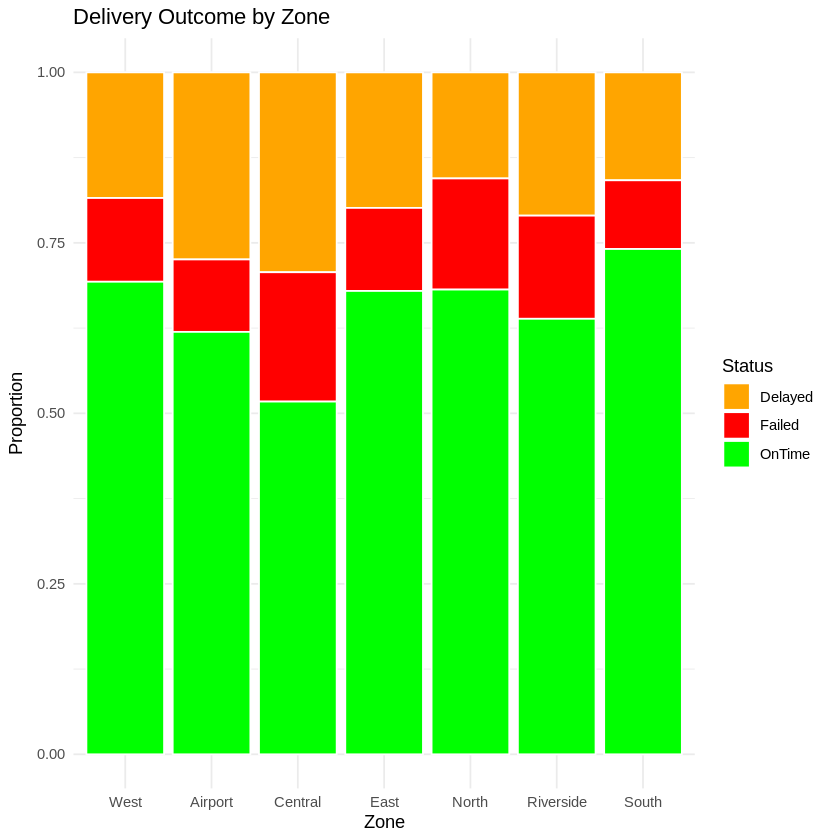

In [55]:
# Delivery outcome by zone
zone_long <- master_r %>%
  count(pickup_zone, delivery_status) %>%
  group_by(pickup_zone) %>%
  mutate(pct = n / sum(n)) %>%
  ungroup()

ggplot(zone_long, aes(x=reorder(pickup_zone, -pct), y=pct, fill=delivery_status)) +
  geom_bar(stat="identity", colour="white") +
  scale_fill_manual(values=c("OnTime"="green","Delayed"="orange","Failed"="red")) +
  labs(title="Delivery Outcome by Zone", x="Zone", y="Proportion", fill="Status") +
  theme_minimal()

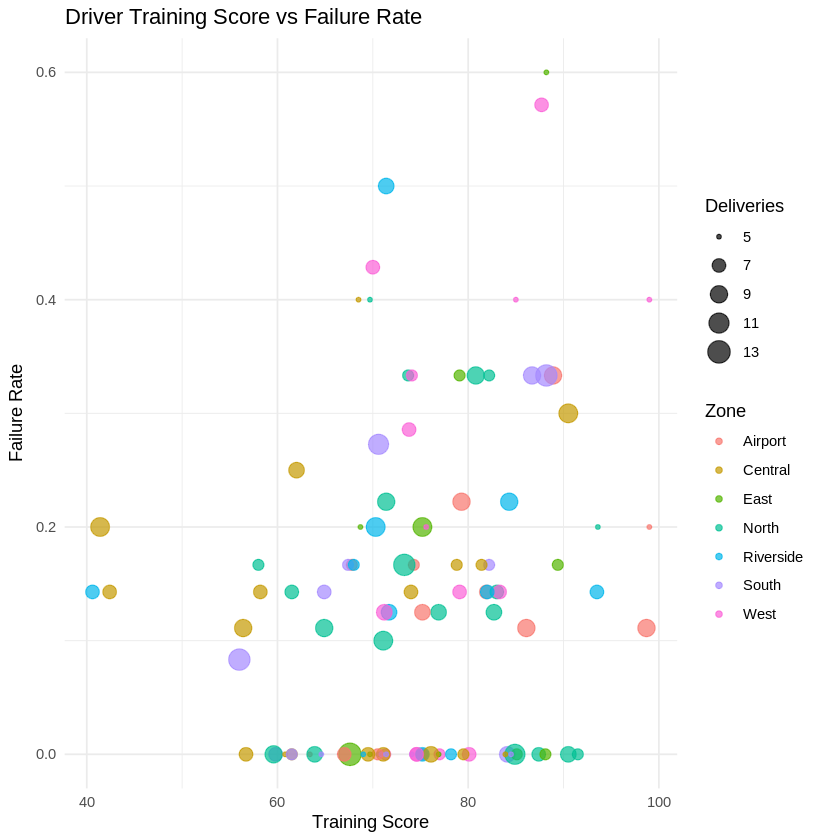

In [56]:
# Driver training score vs failure rate
driver_zone <- deliveries %>%
  left_join(drivers %>% select(driver_id, training_score, base_zone), by="driver_id") %>%
  group_by(driver_id, base_zone, training_score) %>%
  summarise(failure_rate=mean(is_failed), n=n(), .groups="drop") %>%
  filter(n >= 5, !is.na(training_score))

ggplot(driver_zone, aes(x=training_score, y=failure_rate, colour=base_zone, size=n)) +
  geom_point(alpha=0.7) +
  labs(title="Driver Training Score vs Failure Rate",
       x="Training Score", y="Failure Rate", colour="Zone", size="Deliveries") +
  theme_minimal()

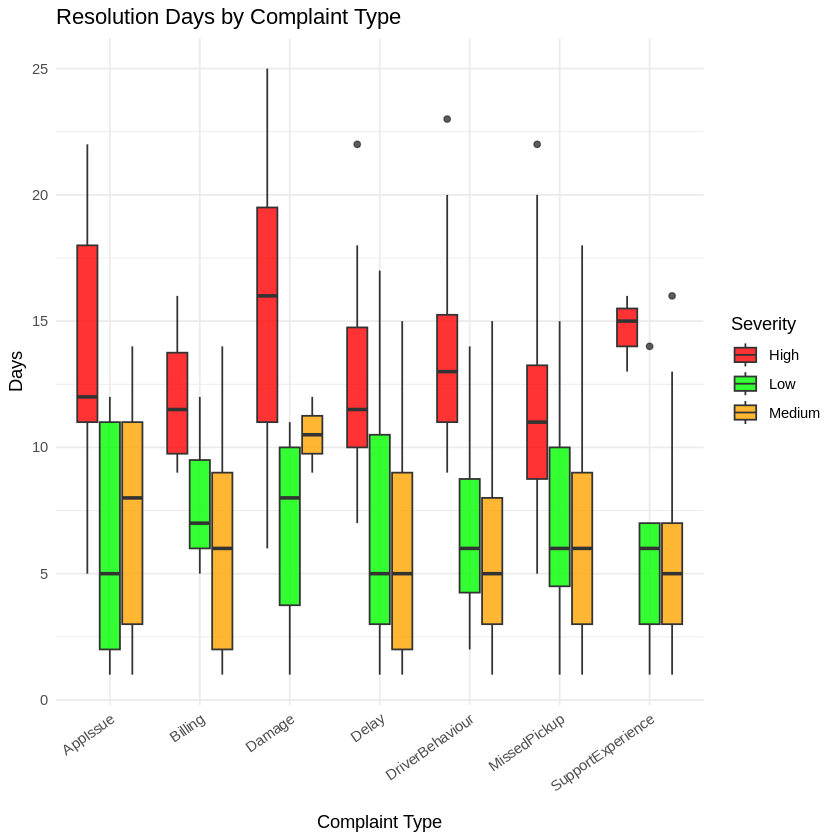

In [57]:
# Complaint resolution days by type
ggplot(complaints[!is.na(complaints$resolution_days), ],
       aes(x=complaint_type, y=resolution_days, fill=severity)) +
  geom_boxplot(alpha=0.8) +
  scale_fill_manual(values=c("High"="red","Medium"="orange","Low"="green")) +
  labs(title="Resolution Days by Complaint Type", x="Complaint Type", y="Days", fill="Severity") +
  theme_minimal() +
  theme(axis.text.x=element_text(angle=35, hjust=1))